<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>MLP using SciKitLearn - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [1]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [2]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [3]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [4]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow', newline=True):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
        
    # Newline - defaul to a newline
    nl=None if newline else ' '
    
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}', end=nl)

### Check for Internet Access

In [5]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [6]:
internet_required = False

In [7]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load the Dataset

In [8]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')

In [9]:
df.sample(10)

,age,default,balance,housing,loan,day,y,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
6510,0.389610,0.0,0.078496,1.0,0.0,0.866667,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
22435,0.220779,0.0,0.073294,0.0,0.0,0.700000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8022,0.168831,0.0,0.074537,1.0,0.0,0.033333,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
37,0.454545,0.0,0.072776,0.0,0.0,0.133333,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
38316,0.103896,0.0,0.072195,1.0,0.0,0.466667,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4033,0.493506,0.0,0.073003,1.0,0.0,0.500000,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2406,0.506494,0.0,0.082354,1.0,0.0,0.400000,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2588,0.506494,0.0,0.072803,0.0,0.0,0.400000,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
40261,0.194805,0.0,0.103081,0.0,0.0,0.466667,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
15617,0.168831,0.0,0.079830,1.0,1.0,0.666667,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Now it is necessary to split the input dataset into two parts - testing and training data

In [10]:
# Split data frame into 80/20
df_train = df.sample(frac = 0.8)
# Creating dataframe with rest of the 20% values
df_test = df.drop(df_train.index)

In [11]:
print_output("df_train shape", df_train.shape)
print_output("df_test shape", df_test.shape)

df_train shape: (36169, 45)
df_test shape: (9042, 45)


In [12]:
# Split datasets into X (features) and y (labels)
df_X_train = df_train.drop(columns='y')
df_y_train = df_train['y']

df_X_test = df_test.drop(columns='y')
df_y_test = df_test['y']


In [13]:
df_X_train.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'month_apr', 'month_aug', 'month_dec', 'month_feb',
       'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'poutcome_failure',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='str')

# Neural Network

"Construct a three-layer feedforward neural network consisting of N input neurons, 10 hidden neurons, and M output neuron(s)."

In a neural network, the forward pass consists of two main operations per layer:

    Linear Transformation: Z=X⋅W+b

    Activation Function: A=σ(Z)

For a binary classification task like this, the Sigmoid function is the standard choice for the output layer because it squashes any input into a value between 0 and 1, which we can interpret as a probability.  (citation)

## MLP Class 

In [23]:
class MLP_From_Scratch:

    # Constructor
    def __init__(self, X_train, y_train, X_test, y_test, **kwargs):

        # Handle Arguments
        _random_seed = kwargs.get('random_seed', 67)
        self.debug = kwargs.get('debug', False)

        self.validation_split = kwargs.get('validation_split', 0.2)    # Default to 20% of the training data

        # Split off validation dataset from the training data
        val_X = X_train.sample(frac=self.validation_split, random_state=_random_seed)
        val_y = y_train.loc[val_X.index]

        # Convert provided data to numpy arrays
        self.X_np_train = X_train.to_numpy()
        self.y_np_train = y_train.to_numpy().reshape(-1,1)

        self.X_np_val = val_X.to_numpy()
        self.y_np_val = val_y.to_numpy().reshape(-1,1)

        self.X_np_test = X_test.to_numpy()
        self.y_np_test = y_test.to_numpy().reshape(-1,1)

        # Additional Model Parameters
        _act_func = kwargs.get('act_func', 'sigmoid')
        _no_hidden_neurons = kwargs.get('no_hidden_neurons', 10)    # Defaults to 10 hidden neurons, per assessment specification
        _no_output_neurons = kwargs.get('no_output_neurons', 1)

        # Define Model Parameters
        self.no_input_neurons  = self.X_np_train.shape[1]    # Set dynamically based on the input dataset
        self.no_hidden_neurons = _no_hidden_neurons          
        self.no_output_neurons = _no_output_neurons
        self.learning_rate = 0.03          

        # Initialize Weights with small random numbers
        # 
        #   input_neurons --> weights_0 --> hidden_neurons --> weights_1 --> output_neurons
        #                                   biases_1                         biases_2
        #
        np.random.seed(_random_seed)

        self.weights_0 = np.random.randn(self.no_input_neurons, self.no_hidden_neurons) 
        self.weights_1 = np.random.randn(self.no_hidden_neurons, self.no_output_neurons)

        self.biases_1 = np.zeros((1, self.no_hidden_neurons))
        self.biases_2 = np.zeros((1, self.no_output_neurons))


        if self.debug:
            print_output("No Input Layer Neurons", self.no_input_neurons, colour='blue')
            print_output("No Input to Hidden Weights", self.weights_0.size)

            print_output("No Hidden Layer Neurons", self.no_hidden_neurons, colour='blue')
            print_output("No Hidden Layer Biases", self.biases_1.size, colour='blue')

            print_output("No Hidden to Output Weights", self.weights_1.size)

            print_output("No Output Layer Neurons", self.no_output_neurons, colour='blue')
            print_output("No Output Layer Biases", self.biases_2.size, colour='blue')


    # end Constructor

    # ***** Activation Functions 

    def _relu(self, x):
        return np.maximum(0, x)

    def _relu_derivative(self, x):
        return (x > 0).astype(float)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return x * (1 - x)

    # Generic version to allow replacement
    def _act_func(self, x):
        return self._sigmoid(x)

    def _act_func_deriv(self, x):
        return self._sigmoid_derivative(x)
    
    # ***** MLP Process Functions 

    def _feed_forward(self, X):
        sum_synapse_0 = np.dot(X, self.weights_0) + self.biases_1
        hidden_layer = self._act_func(sum_synapse_0)
        
        sum_synapse_1 = np.dot(hidden_layer, self.weights_1) + self.biases_2
        output_layer = self._act_func(sum_synapse_1)
        
        # Return everything
        return X, hidden_layer, output_layer
    

    def _back_propagation(self, output_layer):
        error_output_layer = self.y_np_train - output_layer
        average_error = np.mean(abs(error_output_layer))
        
        derivative_output = self._act_func_deriv(output_layer)
        delta_output = error_output_layer * derivative_output

        return delta_output, average_error
    
    
    def _back_propagation_hidden(self, delta_output, hidden_layer):
    
        # Transpose the numpy array
        weights_1T = self.weights_1.T
        
        delta_output_weight = delta_output.dot(weights_1T)
        delta_hidden_layer = delta_output_weight * self._act_func_deriv(hidden_layer)
        
        hidden_layerT = hidden_layer.T
        input_x_delta1 = hidden_layerT.dot(delta_output)

        return delta_hidden_layer, input_x_delta1
    

    def _weight_bias_update(self, input_layer, input_x_delta1, delta_hidden_layer, delta_output):
        #global weights_0, weights_1, biases_1, biases_2, learning_rate

        m = input_layer.shape[0]                                                          # Batch size to normalise the gradient
        
        self.weights_1 = self.weights_1 + (input_x_delta1 / m * self.learning_rate)       # Divide by m to compute the average gradient
        
        input_layerT = input_layer.T
        input_x_delta0 = input_layerT.dot(delta_hidden_layer)
        self.weights_0 = self.weights_0 + (input_x_delta0 / m * self.learning_rate)                                                            

        self.biases_1 = self.biases_1 + np.sum(delta_hidden_layer, axis=0, keepdims=True) / m * self.learning_rate
        self.biases_2 = self.biases_2 + np.sum(delta_output, axis=0, keepdims=True) / m * self.learning_rate 


    def calculate_accuracy(self, X, y):
        _, _, output = self._feed_forward(X)
        predictions = (output > 0.5).astype(int)
        return np.mean(predictions == y) * 100

    # ***** Public Functions 

    def train_network_old (self, epochs, **kwargs):
        
        # Set up parameters
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.error = []

        # Loop through the training epochs
        for epoch in range(epochs):
            input_layer, hidden_layer, output_layer = self._feed_forward(self.X_np_train)       # Calling feedForward method

            delta_output, average_error = self._back_propagation(output_layer)                                             # Calling backPropagation method

            if epoch % 100 == 0:
                self.error.append(average_error)
                if self.debug:
                    print_output('Epoch', str(epoch + 1) + " ", newline=False)
                    print_output('Error', str(average_error))
                

            delta_hidden_layer, input_x_delta1 = self._back_propagation_hidden(delta_output, hidden_layer)                # Calling backPropagationHidden method

            self._weight_bias_update(input_layer, input_x_delta1, delta_hidden_layer, delta_output)                       # Calling weightBiasUpdate method

    def train_network(self, epochs, **kwargs):

        # Set up parameters
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.train_error_history = []
        self.valid_error_history = [] # To track validation

        for epoch in range(epochs):

            # Forward
            input_layer, hidden_layer, output_layer = self._feed_forward(self.X_np_train)
            
            # Backprop (Output)
            delta_output, train_error = self._back_propagation(output_layer)
            
            # Backprop (Hidden)
            delta_hidden_layer, input_x_delta1 = self._back_propagation_hidden(delta_output, hidden_layer)
            
            # Update Weights
            self._weight_bias_update(input_layer, input_x_delta1, delta_hidden_layer, delta_output)


            if epoch % 100 == 0:
                # We use the SAME feed_forward method but with TEST data
                _, _, test_output = self._feed_forward(self.X_np_test)
                
                # Calculate validation error (Mean Absolute Error)
                valid_error = np.mean(np.abs(self.y_np_test - test_output))
                
                self.train_error_history.append(train_error)
                self.valid_error_history.append(valid_error)

                if self.debug:
                    print(f"Epoch {epoch}: Train Error: {train_error:.4f} | Valid Error: {valid_error:.4f}")
                    

    def evaluate(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test
                
        # 1. Run the forward pass (Prediction)
        _, _, output_layer = self._feed_forward(X_data)
           
        # 2. Convert probabilities to binary 0 or 1
        # If the network says 0.8, we count that as "Yes" (1)
        predictions = (output_layer > 0.5).astype(int)
            
        # 3. Compare with actual y values
        accuracy = np.mean(predictions == y_data) * 100
            
        return accuracy

    def plot_error(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.train_error_history, label='Training Error')
        plt.plot(self.valid_error_history, label='Validation Error', linestyle='--')
        plt.xlabel('Epochs (x100)')
        plt.ylabel('Mean Absolute Error')
        plt.title('Training vs Validation Error')
        plt.legend()
        plt.show()


    def _get_confusion_matrix(self, y_true, y_pred_probs):
        # Convert probabilities to 0 or 1
        y_pred = (y_pred_probs > 0.5).astype(int)
        
        # Ensure they are flat arrays for easy comparison
        y_true = y_true.flatten()
        y_pred = y_pred.flatten()
        
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        
        return np.array([[tn, fp], [fn, tp]])
    

    def plot_confusion_matrix(self, matrix):
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(matrix, cmap='Blues')

        # Add colorbar
        plt.colorbar(im)

        # Set labels
        classes = ['No (0)', 'Yes (1)']
        ax.set_xticks(np.arange(len(classes)))
        ax.set_yticks(np.arange(len(classes)))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        # Rotate the tick labels and set their alignment.
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

        # Loop over data dimensions and create text annotations.
        for i in range(2):
            for j in range(2):
                text = ax.text(j, i, matrix[i, j],
                            ha="center", va="center", color="black", fontsize=14)

        ax.set_title("Confusion Matrix Heatmap")
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        plt.tight_layout()
        plt.show()

    # Text Representation
    def print_confusion_matrix(self,matrix):
        print("\n--- Confusion Matrix (Text Table) ---")
        print(f"{'':>15} | {'Predicted No':>12} | {'Predicted Yes':>12} |")
        print("-" * 48)
        print(f"{'Actual No':>15} | {matrix[0][0]:>12} | {matrix[0][1]:>12} |")
        print(f"{'Actual Yes':>15} | {matrix[1][0]:>12} | {matrix[1][1]:>12} |")
        print("-" * 48)

    # Export the model weights and biases to a JSON file
    def save_weights(self, filename):
        weights_data = {
            'weights_0': self.weights_0.tolist(),
            'weights_1': self.weights_1.tolist(),
            'biases_1': self.biases_1.tolist(),
            'biases_2': self.biases_2.tolist()
        }
        with open(filename, 'w') as f:
            json.dump(weights_data, f)

    # Load the model weights and biases from a JSON file
    def load_weights(self, filename):
        with open(filename, 'r') as f:
            weights_data = json.load(f)
            self.weights_0 = np.array(weights_data['weights_0'])
            self.weights_1 = np.array(weights_data['weights_1'])
            self.biases_1 = np.array(weights_data['biases_1'])
            self.biases_2 = np.array(weights_data['biases_2'])
        

This is a binary classification problem, which implies 1 output neuron

No Input Layer Neurons: 44
No Input to Hidden Weights: 440
No Hidden Layer Neurons: 10
No Hidden Layer Biases: 10
No Hidden to Output Weights: 10
No Output Layer Neurons: 1
No Output Layer Biases: 1
Epoch 0: Train Error: 0.7863 | Valid Error: 0.7824
Epoch 100: Train Error: 0.6465 | Valid Error: 0.6436
Epoch 200: Train Error: 0.4382 | Valid Error: 0.4387
Epoch 300: Train Error: 0.3292 | Valid Error: 0.3318
Epoch 400: Train Error: 0.2798 | Valid Error: 0.2833
Epoch 500: Train Error: 0.2532 | Valid Error: 0.2570
Epoch 600: Train Error: 0.2368 | Valid Error: 0.2409
Epoch 700: Train Error: 0.2257 | Valid Error: 0.2299
Epoch 800: Train Error: 0.2178 | Valid Error: 0.2221
Epoch 900: Train Error: 0.2118 | Valid Error: 0.2162
Epoch 1000: Train Error: 0.2072 | Valid Error: 0.2116
Epoch 1100: Train Error: 0.2035 | Valid Error: 0.2080
Epoch 1200: Train Error: 0.2006 | Valid Error: 0.2051
Epoch 1300: Train Error: 0.1982 | Valid Error: 0.2027
Epoch 1400: Train Error: 0.1961 | Valid Error: 0.2007
Epo

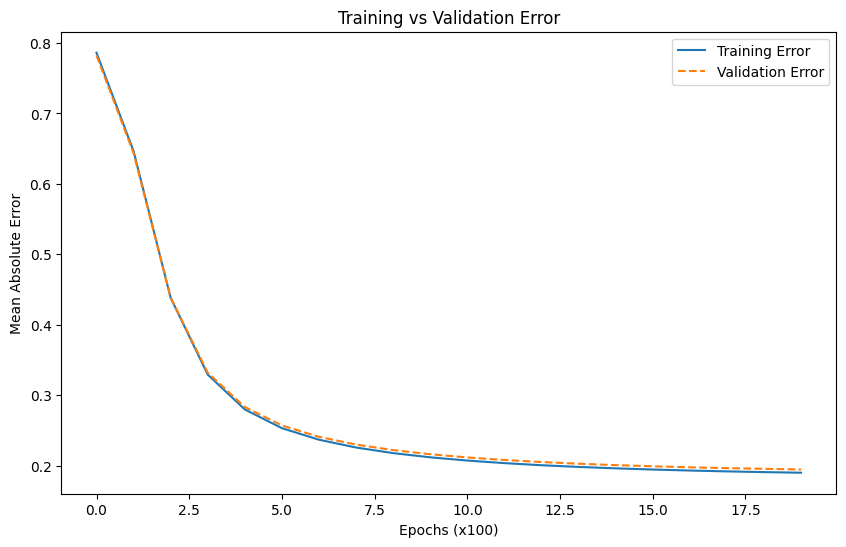

In [24]:
del mlp
mlp = MLP_From_Scratch(df_X_train, df_y_train, df_X_test, df_y_test, debug=True)
mlp.train_network(epochs=2000)
mlp.plot_error()


In [25]:
mlp.calculate_accuracy(mlp.X_np_test, mlp.y_np_test)

np.float64(87.80137137801371)

In [26]:
final_test_score = mlp.evaluate()
print(f"Final Model Accuracy on Unseen Data: {final_test_score:.2f}%")

Final Model Accuracy on Unseen Data: 87.80%



--- Confusion Matrix (Text Table) ---
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         7937 |           13 |
     Actual Yes |         1090 |            2 |
------------------------------------------------


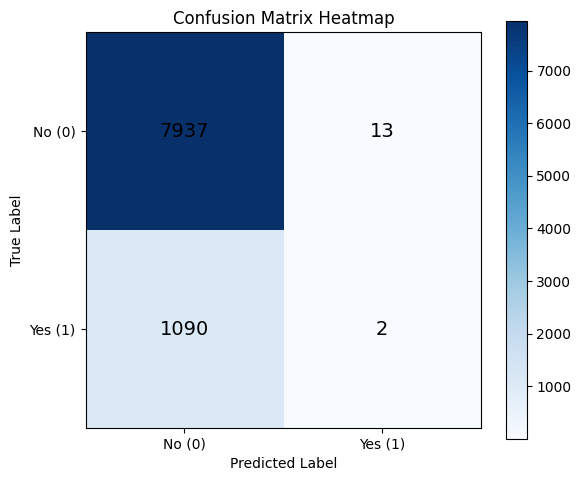

In [28]:
# 1. Get predictions from your trained model
_, _, test_probs = mlp._feed_forward(mlp.X_np_test)

# 2. Generate matrix
cm = mlp._get_confusion_matrix(mlp.y_np_test, test_probs)

# 3. Show results
mlp.print_confusion_matrix(cm)
mlp.plot_confusion_matrix(cm)

In [18]:
sys.exit('Stopping notebook run here.')   

SystemExit: Stopping notebook run here.

Notes for report:

Why use a Validation set instead of just the Test set?

If you use your Test set to decide when to stop training or what learning rate to use, you are technically "leaking" information. You might end up with a model that performs great on that specific Test set but fails in the real world. By using a Validation set, you keep the Test set completely "unseen" until the very final moment of your project.


Three Crucial "Scratch" Tips for your Assessment:

1. The "Sign" of your Update: In your _weight_bias_update, you are using:
self.weights_1 = self.weights_1 + (input_x_delta1 ...)
Normally, Gradient Descent subtracts the gradient. However, because you calculated error_output_layer as Target - Output (which is the negative gradient), using + is mathematically correct here. Just keep an eye on that!

2. Accuracy vs. Error:
Error (MAE) is great for the math, but your assessment likely wants to see Accuracy. You can add a quick method to calculate how many predictions were correct:

To know how "wrong" the network is, we use Binary Cross-Entropy Loss (also called Log Loss). This is much more effective for classification than Mean Squared Error.
Loss=−m1​∑[y⋅log(y^​)+(1−y)⋅log(1−y^​)]

``` --- Confusion Matrix (Text Table) ---
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         7937 |           13 |
     Actual Yes |         1090 |            2 |
------------------------------------------------
```

I was getting the above confusion matrix which means that:

You’ve just hit the most important lesson in classification: Accuracy is a liar.

If we look at your raw accuracy, it’s roughly 87% (7939/9042). On paper, that looks like an "B+." But looking at your Confusion Matrix, your model has a major problem called the Majority Class Bias.
The "Lazy" Model Problem

Because about 88% of your customers said "No" in the original dataset, your neural network has learned a "lazy" shortcut: "If I just say 'No' to everyone, I'll be right 88% of the time!"

Let's look at your Recall for people who actually said Yes:

    Total actual "Yes" customers: 1,092

    "Yes" customers you actually found (True Positives): 2

    Recall: 2/1092=0.18%

Your model is essentially invisible to the very people the bank wants to find. It caught 2 people and missed 1,090.
Why is this happening?

    Class Imbalance: Your "No" samples vastly outnumber your "Yes" samples. The loss function (Binary Cross-Entropy) is being "pulled" much harder by the "No" errors than the "Yes" errors.

    Learning Rate & Epochs: Your model might be stuck in a "local minimum" where it’s afraid to predict "Yes" because the "penalty" for being wrong (a False Positive) is outweighed by the sheer volume of "No" cases.

    Sigmoid Saturation: If your weights were initialized too large or your learning rate is too high, the output might be getting "stuck" near 0.

How to fix it (The "Scratch" Way)

Since you are building this yourself, you have two main levers to pull:
1. Adjust the Decision Threshold

Currently, you are likely using (output > 0.5). Because the model is so biased, its "Yes" probabilities might all be very low (e.g., 0.1 or 0.2).

    Try this: Change your prediction line to (output > 0.1) and see what happens to the Confusion Matrix. You will get more False Positives, but your True Positives will jump up.

2. Weighted Loss (The Pro Move)

You can modify your back_propagation or weight_bias_update to "punish" the model more when it misses a "Yes."

    In your code, when the target is 1 but the model predicts 0, multiply that specific gradient by 5 or 10. This forces the weights to care more about the minority class.

3. Oversampling (The Data Move)

Before converting to NumPy, you can duplicate the "Yes" rows in your training DataFrame until the counts are roughly equal. This is called ROS (Random Over-Sampling).

Would you like to try the "Threshold Adjustment" first? It's a one-line code change that will immediately show you if the model has actually learned anything about the "Yes" customers.

In [ ]:
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    # Adding a tiny epsilon (1e-15) prevents log(0) which would result in NaN
    loss = -1/m * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))
    return loss

---